# ハッブル＝ルメートルの法則 — 銀河団データの分析\n\n理科年表(令和8年)の銀河団データを用いて、等級 $m$ と赤方偏移 $z$ の関係を可視化する。

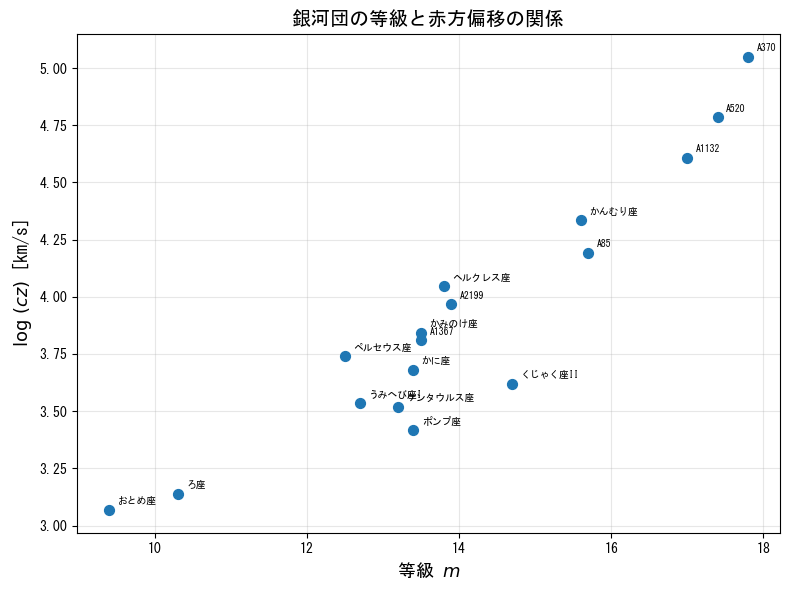

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# 日本語フォント設定
matplotlib.rcParams["font.family"] = "MS Gothic"
matplotlib.rcParams["axes.unicode_minus"] = False

# 銀河団データ (理科年表令和8年)
data = {
    "name": [
        "おとめ座", "ろ座", "ポンプ座", "ケンタウルス座", "うみへび座I",
        "くじゃく座II", "かに座", "ペルセウス座", "A1367", "かみのけ座",
        "A2199", "ヘルクレス座", "A85", "かんむり座", "A1132", "A520", "A370",
    ],
    "m": [9.4, 10.3, 13.4, 13.2, 12.7, 14.7, 13.4, 12.5, 13.5, 13.5,
          13.9, 13.8, 15.7, 15.6, 17.0, 17.4, 17.8],
    "z": [0.0039, 0.0046, 0.0087, 0.0110, 0.0114, 0.0139, 0.0160, 0.0183,
          0.0215, 0.0232, 0.0309, 0.0371, 0.0518, 0.0721, 0.135, 0.203, 0.373],
}

c = 3.0e5  # 光速 [km/s]
m = np.array(data["m"])
z = np.array(data["z"])
log_cz = np.log10(c * z)

# 散布図: 横軸 等級 m, 縦軸 log(cz)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(m, log_cz, s=50, zorder=5)

for i, name in enumerate(data["name"]):
    ax.annotate(name, (m[i], log_cz[i]), fontsize=7, textcoords="offset points", xytext=(6, 4))

ax.set_xlabel("等級 $m$", fontsize=13)
ax.set_ylabel(r"$\log\,(cz)$ [km/s]", fontsize=13)
ax.set_title("銀河団の等級と赤方偏移の関係", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

最小二乗法の結果: m = 3.838 * log(cz) + -0.992


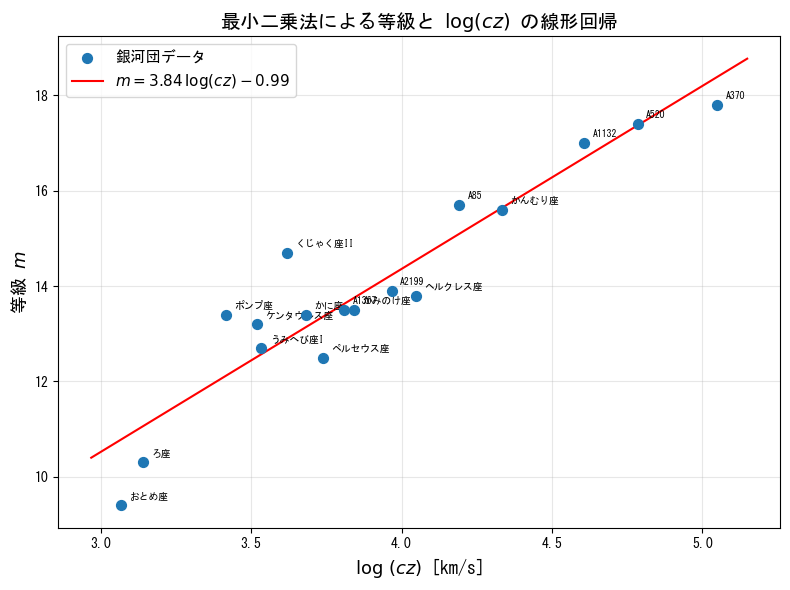

In [2]:
# 最小二乗法: m = a * log(cz) + b
# log_cz を説明変数、m を目的変数として1次フィッティング
a, b = np.polyfit(log_cz, m, 1)
print(f"最小二乗法の結果: m = {a:.3f} * log(cz) + {b:.3f}")

# 回帰直線付き散布図
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(log_cz, m, s=50, zorder=5, label="銀河団データ")

x_fit = np.linspace(log_cz.min() - 0.1, log_cz.max() + 0.1, 100)
y_fit = a * x_fit + b
ax.plot(x_fit, y_fit, "r-", linewidth=1.5, label=f"$m = {a:.2f}\\,\\log(cz) {b:+.2f}$")

for i, name in enumerate(data["name"]):
    ax.annotate(name, (log_cz[i], m[i]), fontsize=7, textcoords="offset points", xytext=(6, 4))

ax.set_xlabel(r"$\log\,(cz)$ [km/s]", fontsize=13)
ax.set_ylabel("等級 $m$", fontsize=13)
ax.set_title("最小二乗法による等級と $\\log(cz)$ の線形回帰", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

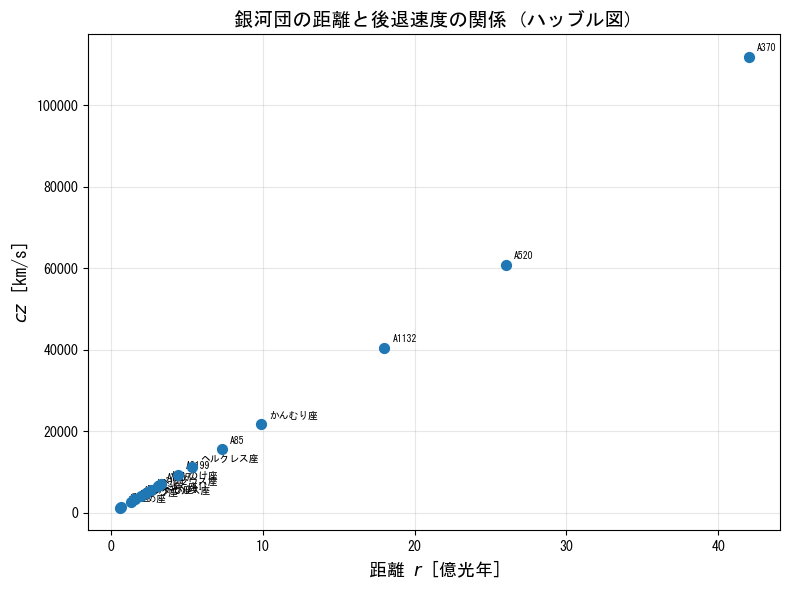

In [3]:
# 距離 r [億光年] (理科年表のデータ)
r = np.array([0.57, 0.67, 1.3, 1.5, 1.6, 2.0, 2.3, 2.6, 3.1, 3.3,
              4.4, 5.3, 7.3, 9.9, 18, 26, 42])

cz = c * z  # 後退速度 [km/s]

# 散布図: 横軸 距離 r, 縦軸 cz
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(r, cz, s=50, zorder=5)

for i, name in enumerate(data["name"]):
    ax.annotate(name, (r[i], cz[i]), fontsize=7, textcoords="offset points", xytext=(6, 4))

ax.set_xlabel("距離 $r$ [億光年]", fontsize=13)
ax.set_ylabel("$cz$ [km/s]", fontsize=13)
ax.set_title("銀河団の距離と後退速度の関係 (ハッブル図)", fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

最小二乗法によるハッブル定数: H = 81.70 [km/s/Mpc]
(参考: プランク衛星の値 H = 67.15 ± 1.2 [km/s/Mpc])


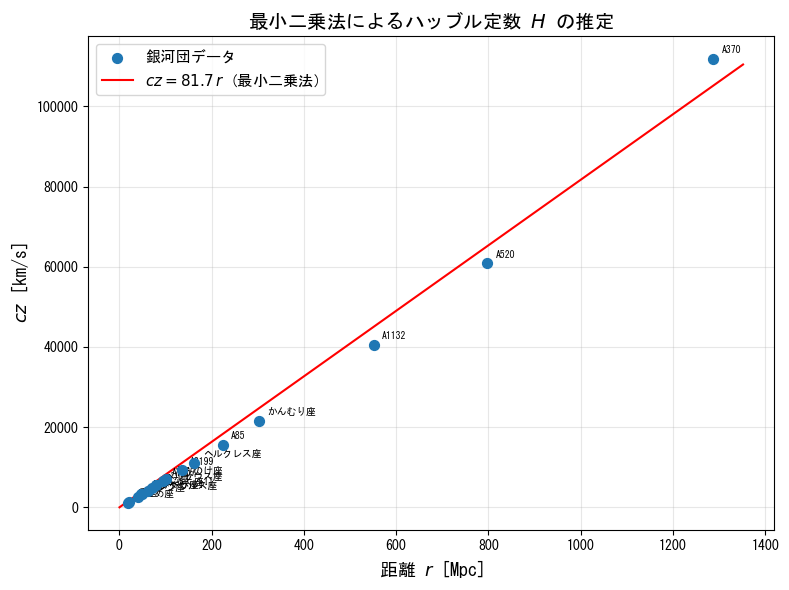

In [4]:
# 最小二乗法: cz = H * r (原点を通る直線)
# 億光年 → Mpc に変換 (1億光年 ≈ 30.66 Mpc)
r_mpc = r * 30.66

# 原点を通る直線 cz = H * r の最小二乗法: H = Σ(r*cz) / Σ(r^2)
H = np.sum(r_mpc * cz) / np.sum(r_mpc**2)
print(f"最小二乗法によるハッブル定数: H = {H:.2f} [km/s/Mpc]")
print(f"(参考: プランク衛星の値 H = 67.15 ± 1.2 [km/s/Mpc])")

# 回帰直線付き散布図
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(r_mpc, cz, s=50, zorder=5, label="銀河団データ")

r_fit = np.linspace(0, r_mpc.max() * 1.05, 100)
cz_fit = H * r_fit
ax.plot(r_fit, cz_fit, "r-", linewidth=1.5, label=f"$cz = {H:.1f}\\,r$ (最小二乗法)")

for i, name in enumerate(data["name"]):
    ax.annotate(name, (r_mpc[i], cz[i]), fontsize=7, textcoords="offset points", xytext=(6, 4))

ax.set_xlabel("距離 $r$ [Mpc]", fontsize=13)
ax.set_ylabel("$cz$ [km/s]", fontsize=13)
ax.set_title("最小二乗法によるハッブル定数 $H$ の推定", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

相対論的補正あり: H = 70.27 [km/s/Mpc]
近似 v=cz の場合:  H = 81.70 [km/s/Mpc]
(参考: プランク衛星の値 H = 67.15 ± 1.2 [km/s/Mpc])


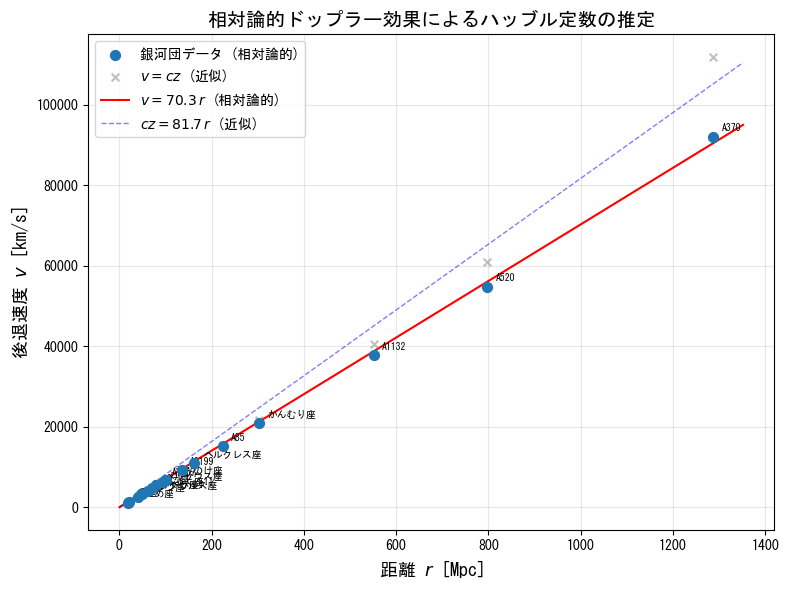

In [5]:
# 相対論的ドップラー効果による後退速度
# v/c = (2z + z^2) / (2 + 2z + z^2)
v_rel = c * (2 * z + z**2) / (2 + 2 * z + z**2)

# 原点を通る直線 v = H * r の最小二乗法
H_rel = np.sum(r_mpc * v_rel) / np.sum(r_mpc**2)
print(f"相対論的補正あり: H = {H_rel:.2f} [km/s/Mpc]")
print(f"近似 v=cz の場合:  H = {H:.2f} [km/s/Mpc]")
print(f"(参考: プランク衛星の値 H = 67.15 ± 1.2 [km/s/Mpc])")

# 比較プロット
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(r_mpc, v_rel, s=50, zorder=5, label="銀河団データ (相対論的)")
ax.scatter(r_mpc, cz, s=30, marker="x", color="gray", alpha=0.5, zorder=4, label="$v = cz$ (近似)")

r_fit = np.linspace(0, r_mpc.max() * 1.05, 100)
ax.plot(r_fit, H_rel * r_fit, "r-", linewidth=1.5,
        label=f"$v = {H_rel:.1f}\\,r$ (相対論的)")
ax.plot(r_fit, H * r_fit, "b--", linewidth=1, alpha=0.5,
        label=f"$cz = {H:.1f}\\,r$ (近似)")

for i, name in enumerate(data["name"]):
    ax.annotate(name, (r_mpc[i], v_rel[i]), fontsize=7, textcoords="offset points", xytext=(6, 4))

ax.set_xlabel("距離 $r$ [Mpc]", fontsize=13)
ax.set_ylabel("後退速度 $v$ [km/s]", fontsize=13)
ax.set_title("相対論的ドップラー効果によるハッブル定数の推定", fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()